In [2]:
import os 
import math
import json
import sys
from typing import List, Dict, Tuple, Optional


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#to see column structure

df=pd.read_csv("C:\\Users\\elif_\\Documents\\ttgintt4.csv", sep=';')

df

,CNTRY,IDCNTRY,IDCNTPOP,IDSCHOOL,IDTEACH,IDTQUEST,IDLANG_TQ,ITMODE_TQ,TT4G01,TT4G04,...,TRWGT93,TRWGT94,TRWGT95,TRWGT96,TRWGT97,TRWGT98,TRWGT99,TRWGT100,VERSION,IEADATE
0,ARE,784,ARE1,1001,100101,2,53,1,1,3,...,2.491176,0.830392,2.491176,2.491176,0.830392,2.491176,0.830392,0.830392,3.2,2025-11-05
1,ARE,784,ARE1,1001,100102,3,53,1,1,9,...,9.964704,3.321568,9.964704,9.964704,3.321568,9.964704,3.321568,3.321568,3.2,2025-11-05
2,ARE,784,ARE1,1001,100103,1,1,1,1,3,...,9.964704,3.321568,9.964704,9.964704,3.321568,9.964704,3.321568,3.321568,3.2,2025-11-05
3,ARE,784,ARE1,1001,100104,2,1,1,1,1,...,9.964704,3.321568,9.964704,9.964704,3.321568,9.964704,3.321568,3.321568,3.2,2025-11-05
4,ARE,784,ARE1,1001,100105,3,1,1,1,2,...,9.964704,3.321568,9.964704,9.964704,3.321568,9.964704,3.321568,3.321568,3.2,2025-11-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278378,TUR,792,TUR3,3203,320326,3,35,1,2,1,...,25.348333,76.045000,76.045000,25.348333,25.348333,76.045000,76.045000,25.348333,3.2,2025-11-05
278379,TUR,792,TUR3,3203,320327,1,35,1,1,2,...,25.348333,76.045000,76.045000,25.348333,25.348333,76.045000,76.045000,25.348333,3.2,2025-11-05
278380,TUR,792,TUR3,3203,320328,2,35,1,2,1,...,25.348333,76.045000,76.045000,25.348333,25.348333,76.045000,76.045000,25.348333,3.2,2025-11-05
278381,TUR,792,TUR3,3203,320329,3,35,1,1,1,...,25.348333,76.045000,76.045000,25.348333,25.348333,76.045000,76.045000,25.348333,3.2,2025-11-05


In [4]:
import pandas as pd
import re

#Renaming column names based on the codebook, this one takes little longer to run!

# 1. Load data (semicolon-separated!) and codebook
df = pd.read_csv("C:\\Users\\elif_\\Documents\\ttgintt4.csv", sep=';')    #change here for the path to your Teacher Data
codebook = pd.read_csv("C:\\Users\\elif_\\Documents\\talis2024_teacher_codebook.csv")  #change here to the path to your Teacher Survey codebook

# 2. Turn each description into a short, readable column-name slug
def slugify(text, maxlen=60):
    text = str(text).split('.')[0]            # just the first sentence
    text = text.lower()
    text = re.sub(r'[^a-z0-9]+', '_', text)    # non-alphanumeric -> underscore
    text = re.sub(r'_+', '_', text).strip('_')
    return text[:maxlen].rstrip('_')

codebook['new_name'] = codebook['description'].apply(slugify)

# keep grid items distinguishable (Q7 item A vs item B, etc.)
codebook['new_name'] = codebook.apply(
    lambda r: f"{r['new_name']}_{str(r['item']).lower()}" if pd.notna(r['item']) else r['new_name'],
    axis=1
)

# 3. De-duplicate any names that still collide (e.g. TRWGT1..TRWGT80)
def dedupe(names):
    seen, out = {}, []
    for n in names:
        if n not in seen:
            seen[n] = 0
            out.append(n)
        else:
            seen[n] += 1
            out.append(f"{n}_{seen[n]}")
    return out

codebook['new_name'] = dedupe(codebook['new_name'].tolist())

# 4. Build the rename map and apply it
rename_map = dict(zip(codebook['variable_name'], codebook['new_name']))

unmatched = set(df.columns) - set(rename_map)
if unmatched:
    print(f"⚠️ {len(unmatched)} data columns have no codebook entry, left unchanged:")
    print(sorted(unmatched))

df = df.rename(columns=rename_map)

# 5. Lookup table so you can always get back to the original code/description
column_lookup = codebook.set_index('new_name')[['variable_name', 'description']]
# e.g. column_lookup.loc['gender']

df.head()     #Show the first few rows of the renamed dataframe

print(df.shape)  # to save the renamed dataframe as csv to the same directory
df.to_csv("C:\\Users\\elif_\\Documents\\ttgintt4_renamed.csv", index=False)
column_lookup.to_csv("C:\\Users\\elif_\\Documents\\column_lookup.csv")

(278383, 630)


In [5]:
###Skip here until we start working on Principal Survey####

#This one uses questionnaire pdf to create a codebook file woth pdf parsing.

import pandas as pd
import pdfplumber
import re

# ============================================================
# 0. Install dependency if needed:  pip install pdfplumber
# ============================================================

# ============================================================
# 1. Parse variable codes and descriptions from PDF codebooks
# ============================================================
def parse_codebook_pdf(pdf_path: str) -> pd.DataFrame:
    """
    In TALIS questionnaire PDFs the variable code (e.g. TC4G04A)
    sits at the END of the same line as its item text, e.g.:
      'a) Year(s) working as a principal at this school    TC4G04A'
    We capture the text to the LEFT of the code on that line,
    falling back to the nearest question-stem line above when
    the inline text is too short (e.g. response-scale rows).
    """
    var_re  = re.compile(r'\b(TC4G\d{2,3}[A-Z]?\d?)\b')
    noise_re = re.compile(
        r'(Restricted Use|À usage restreint|TALIS Principal|Page \d+|'
        r'Please mark|Please write|Please enter|PQ_\d+|MS-PQ)',
        re.IGNORECASE
    )

    records   = []
    seen_vars = set()

    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            text = page.extract_text()
            if not text:
                continue

            lines = text.split('\n')
            last_stem = ""   # most recent bold question / sub-question line

            for line in lines:
                # Skip noise lines entirely
                if noise_re.search(line):
                    continue

                # Track the question stem (lines with a question number)
                # e.g. "4.  How many years of work experience..."
                if re.match(r'^\d+[\.\s]', line.strip()) and not var_re.search(line):
                    last_stem = re.sub(r'\s+', ' ', line.strip())

                # Find all variable codes on this line
                codes = var_re.findall(line)
                if not codes:
                    continue

                # Text to the left of the first code = inline description
                first_code = codes[0]
                inline_text = line[:line.index(first_code)].strip()
                inline_text = re.sub(r'\s+', ' ', inline_text)

                # Strip leading a) b) c) markers and dots/numbers
                inline_text = re.sub(r'^[a-z]\)\s*', '', inline_text)
                inline_text = re.sub(r'^[\d]+[\.\s]+', '', inline_text)
                inline_text = inline_text.strip(' .')

                for var in codes:
                    if var in seen_vars:
                        continue
                    seen_vars.add(var)

                    # Use inline text if it's meaningful, else fall back to stem
                    description = inline_text if len(inline_text) > 8 else last_stem
                    description = description[:120]

                    # Parse item suffix (a, b, c... or 1, 2... for multi-column vars)
                    item_match = re.match(r'TC4G\d{2,3}([A-Z])(\d?)$', var)
                    item = (item_match.group(1) + item_match.group(2)).lower() if item_match else None

                    records.append({
                        "variable_name": var,
                        "description":   description,
                        "item":          item,
                    })

    df = pd.DataFrame(records)
    df = df.sort_values('variable_name').reset_index(drop=True)
    return df

print("Parsing ISCED 2-3 codebook PDF...")
principal_codebook_isced23 = parse_codebook_pdf(
    r"C:\Users\elif_\Documents\TALIS2024PrincipalQuestionnaireISCED2-3.pdf"
)

print("Parsing ISCED 1 codebook PDF...")
principal_codebook_isced1 = parse_codebook_pdf(
    r"C:\Users\elif_\Documents\TALIS2024PrincipalQuestionnaireISCED1.pdf"
)

print(f"ISCED 2-3 codebook: {len(principal_codebook_isced23)} variables")
print(f"ISCED 1 codebook:   {len(principal_codebook_isced1)} variables")
print(principal_codebook_isced23.head(20))   # ← sanity check before proceeding

# ============================================================
# 2. Turn each description into a short, readable column-name slug
# ============================================================
def slugify(text, maxlen=60):
    text = str(text).split('.')[0]
    text = text.lower()
    text = re.sub(r'[^a-z0-9]+', '_', text)
    text = re.sub(r'_+', '_', text).strip('_')
    return text[:maxlen].rstrip('_')

for cb in [principal_codebook_isced23, principal_codebook_isced1]:
    cb['new_name'] = cb['description'].apply(slugify)
    cb['new_name'] = cb.apply(
        lambda r: f"{r['new_name']}_{str(r['item']).lower()}" if pd.notna(r['item']) else r['new_name'],
        axis=1
    )

# ============================================================
# 3. De-duplicate any names that still collide
# ============================================================
def dedupe(names):
    seen, out = {}, []
    for n in names:
        if n not in seen:
            seen[n] = 0
            out.append(n)
        else:
            seen[n] += 1
            out.append(f"{n}_{seen[n]}")
    return out

principal_codebook_isced23['new_name'] = dedupe(principal_codebook_isced23['new_name'].tolist())
principal_codebook_isced1['new_name']  = dedupe(principal_codebook_isced1['new_name'].tolist())

# ============================================================
# 4. Build combined rename map
#    ISCED 2-3 as base; ISCED-1-only variables (TC4G30A-G) added on top
# ============================================================
rename_map_principal_isced23 = dict(zip(principal_codebook_isced23['variable_name'], principal_codebook_isced23['new_name']))
rename_map_principal_isced1  = dict(zip(principal_codebook_isced1['variable_name'],  principal_codebook_isced1['new_name']))

isced1_extra_vars = {
    var: name
    for var, name in rename_map_principal_isced1.items()
    if var not in rename_map_principal_isced23
}

if isced1_extra_vars:
    print(f"ℹ️ {len(isced1_extra_vars)} ISCED-1-only variables added to rename map:")
    print(sorted(isced1_extra_vars.keys()))

rename_map_principal = {**rename_map_principal_isced23, **isced1_extra_vars}

# ============================================================
# 5. Load principal data and apply rename map
# ============================================================
df_principal = pd.read_csv("C:\\Users\\elif_\\Documents\\tcgintt4.csv", sep=';')

unmatched = set(df_principal.columns) - set(rename_map_principal)
if unmatched:
    print(f"⚠️ {len(unmatched)} principal columns have no codebook entry, left unchanged:")
    print(sorted(unmatched))

df_principal = df_principal.rename(columns=rename_map_principal)

# ============================================================
# 6. Lookup table to trace back to original code/description
# ============================================================
principal_column_lookup_isced23 = principal_codebook_isced23.set_index('new_name')[['variable_name', 'description']]
principal_column_lookup_isced1  = principal_codebook_isced1.set_index('new_name')[['variable_name', 'description']]

isced1_extra_rows = principal_column_lookup_isced1[
    ~principal_column_lookup_isced1['variable_name'].isin(principal_codebook_isced23['variable_name'])
]

principal_column_lookup = pd.concat([principal_column_lookup_isced23, isced1_extra_rows])

print(df_principal.shape)
df_principal.head()

# ============================================================
# 7. Save renamed file and lookup table
# ============================================================
df_principal.to_csv("C:\\Users\\elif_\\Documents\\tcgintt4_renamed.csv", index=False)
principal_column_lookup.to_csv("C:\\Users\\elif_\\Documents\\tcgintt4_column_lookup.csv")

print("✅ Renamed principal file saved: tcgintt4_renamed.csv")
print("✅ Principal column lookup saved: tcgintt4_column_lookup.csv")

Parsing ISCED 2-3 codebook PDF...
Parsing ISCED 1 codebook PDF...
ISCED 2-3 codebook: 282 variables
ISCED 1 codebook:   289 variables
   variable_name                                        description item
0         TC4G01                               What is your gender?  NaN
1         TC4G02                                   How old are you?  NaN
2         TC4G03  What is the highest level of formal education ...  NaN
3        TC4G04A      Year(s) working as a principal at this school    a
4        TC4G04B  4. How many years of work experience do you ha...    b
5        TC4G04C  4. How many years of work experience do you ha...    c
6        TC4G04D  Year(s) working as a teacher in total (include...    d
7        TC4G04E  4. How many years of work experience do you ha...    e
8         TC4G05  5. Do you currently have a teaching obligation...  NaN
9         TC4G06  What is your current employment status as a pr...  NaN
10       TC4G07A  7. Did the formal <education or training> you

['country_economy_three_letter_code', 'numeric_country_economy_code', 'country_economy_plus_target_population_identifier']
['country_economy_three_letter_code', 'numeric_country_economy_code', 'country_economy_plus_target_population_identifier', 'school_identifier', 'teacher_identifier', 'teacher_questionnaire_version_type_identifier', 'teacher_questionnaire_language_identifier', 'teacher_questionnaire_administration_mode', 'gender', 'type_of_education_completed_for_first_teaching_qualification']
Number of countries/economies: 55
Number of countries/economies: 55


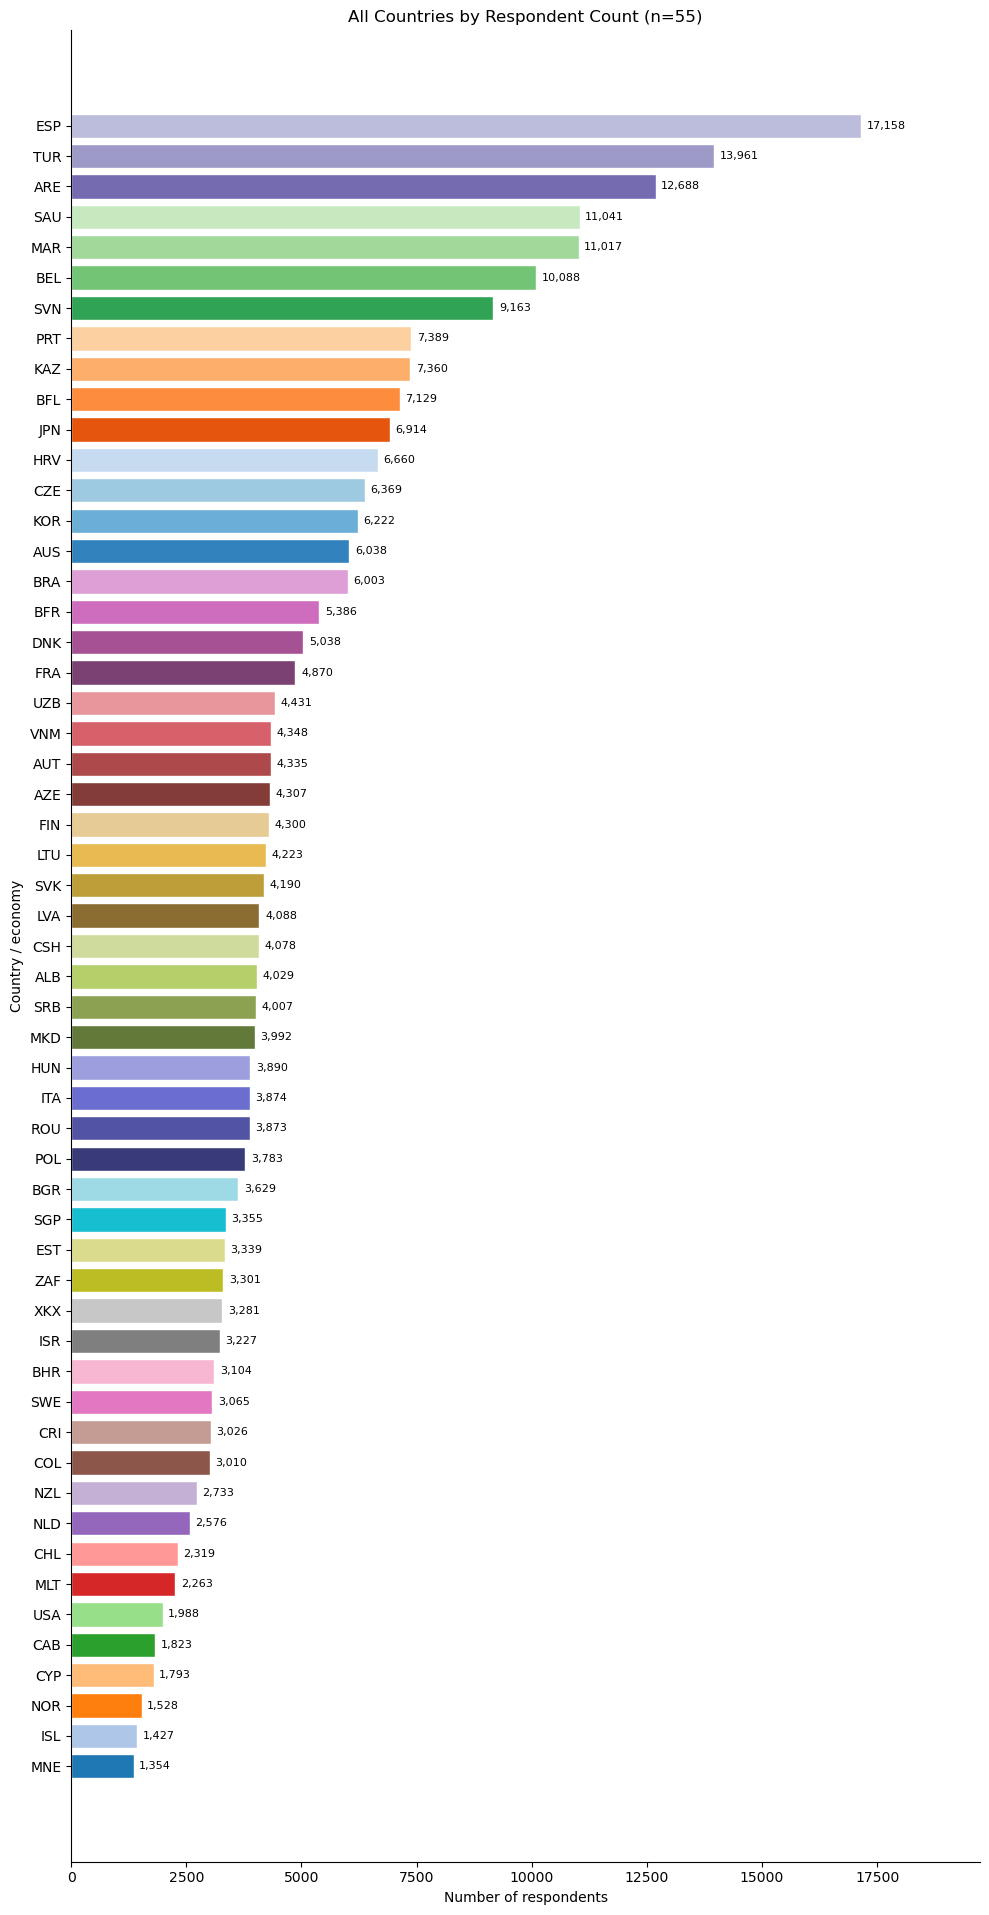

✅ Chart saved: all_countries_respondents.png


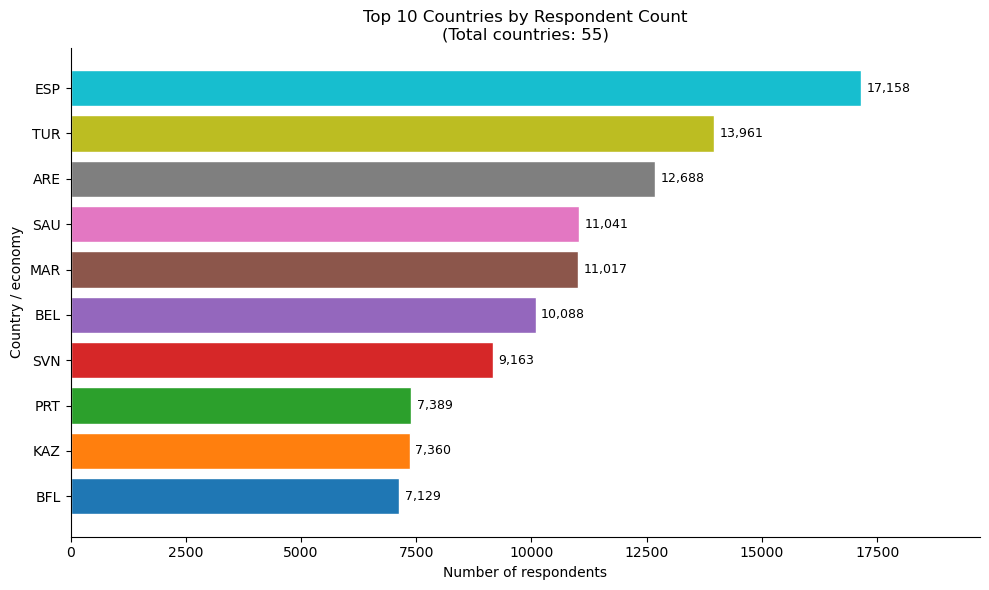

✅ Chart saved: top10_countries_respondents.png


In [10]:
import matplotlib.pyplot as plt
df = pd.read_csv("C:\\Users\\elif_\\Documents\\ttgintt4_renamed.csv")

df = pd.read_csv("C:\\Users\\elif_\\Documents\\ttgintt4_renamed.csv")

# Find the country column
print([c for c in df.columns if 'country' in c.lower() or 'cntry' in c.lower()])
print(df.columns[:10].tolist())  # first 10 columns as backup

# 6. Country counts
country_col = 'country_economy_three_letter_code'

# Number of distinct countries/economies
n_countries = df[country_col].nunique()
print(f"Number of countries/economies: {n_countries}")

# Number of respondents (teachers) per country
respondents_by_country = (
    df[country_col]
    .value_counts()
    .rename_axis('country')
    .reset_index(name='respondent_count')
    .sort_values('country')
    .reset_index(drop=True)
)

respondents_by_country


print(f"Number of countries/economies: {n_countries}")



# ============================================================
# 7. Bar charts — All countries, then Top 10
# ============================================================

all_countries = (
    respondents_by_country
    .sort_values('respondent_count', ascending=True)
)

top10 = (
    respondents_by_country
    .sort_values('respondent_count', ascending=False)
    .head(10)
    .sort_values('respondent_count', ascending=True)
)

# Use a colormap with enough colors for all countries
all_colors  = plt.cm.tab20.colors + plt.cm.tab20b.colors + plt.cm.tab20c.colors
top10_colors = plt.cm.tab10.colors

# ---- Chart 1: All countries ----
fig, ax = plt.subplots(figsize=(10, max(8, len(all_countries) * 0.35)))
bars = ax.barh(
    all_countries['country'],
    all_countries['respondent_count'],
    color=[all_colors[i % len(all_colors)] for i in range(len(all_countries))],
    edgecolor='white'
)
ax.bar_label(bars,
             labels=[f'{v:,}' for v in all_countries['respondent_count']],
             padding=4, fontsize=8)
ax.set_xlim(0, all_countries['respondent_count'].max() * 1.15)
ax.set_xlabel('Number of respondents')
ax.set_ylabel('Country / economy')
ax.set_title(f'All Countries by Respondent Count (n={n_countries})')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(
    "C:\\Users\\elif_\\Documents\\all_countries_respondents.png",
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✅ Chart saved: all_countries_respondents.png")

# ---- Chart 2: Top 10 ----
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    top10['country'],
    top10['respondent_count'],
    color=top10_colors[:len(top10)],
    edgecolor='white'
)
ax.bar_label(bars,
             labels=[f'{v:,}' for v in top10['respondent_count']],
             padding=4, fontsize=9)
ax.set_xlim(0, top10['respondent_count'].max() * 1.15)
ax.set_xlabel('Number of respondents')
ax.set_ylabel('Country / economy')
ax.set_title(f'Top 10 Countries by Respondent Count\n(Total countries: {n_countries})')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(
    "C:\\Users\\elif_\\Documents\\top10_countries_respondents.png",
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✅ Chart saved: top10_countries_respondents.png")


ISCED 1 (Primary): 55,637 respondents across 16 countries


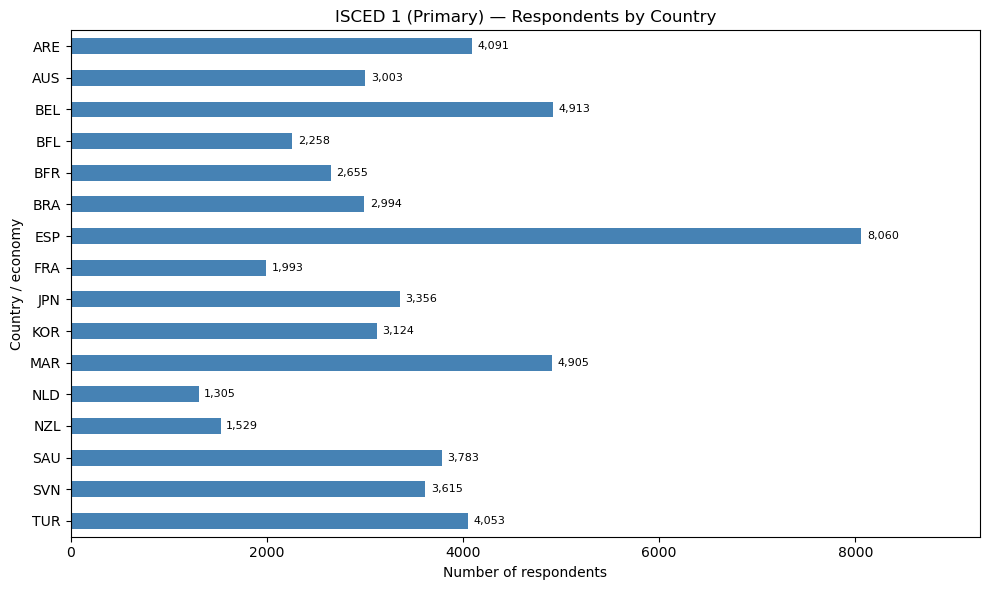

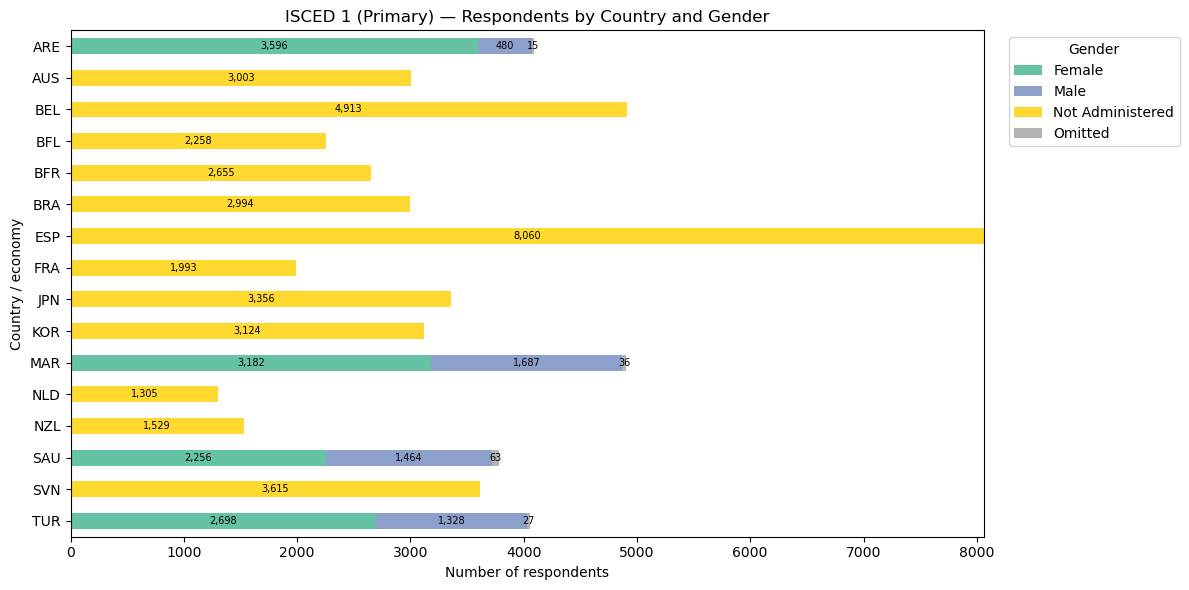


ISCED 2 (Lower Secondary): 194,521 respondents across 55 countries


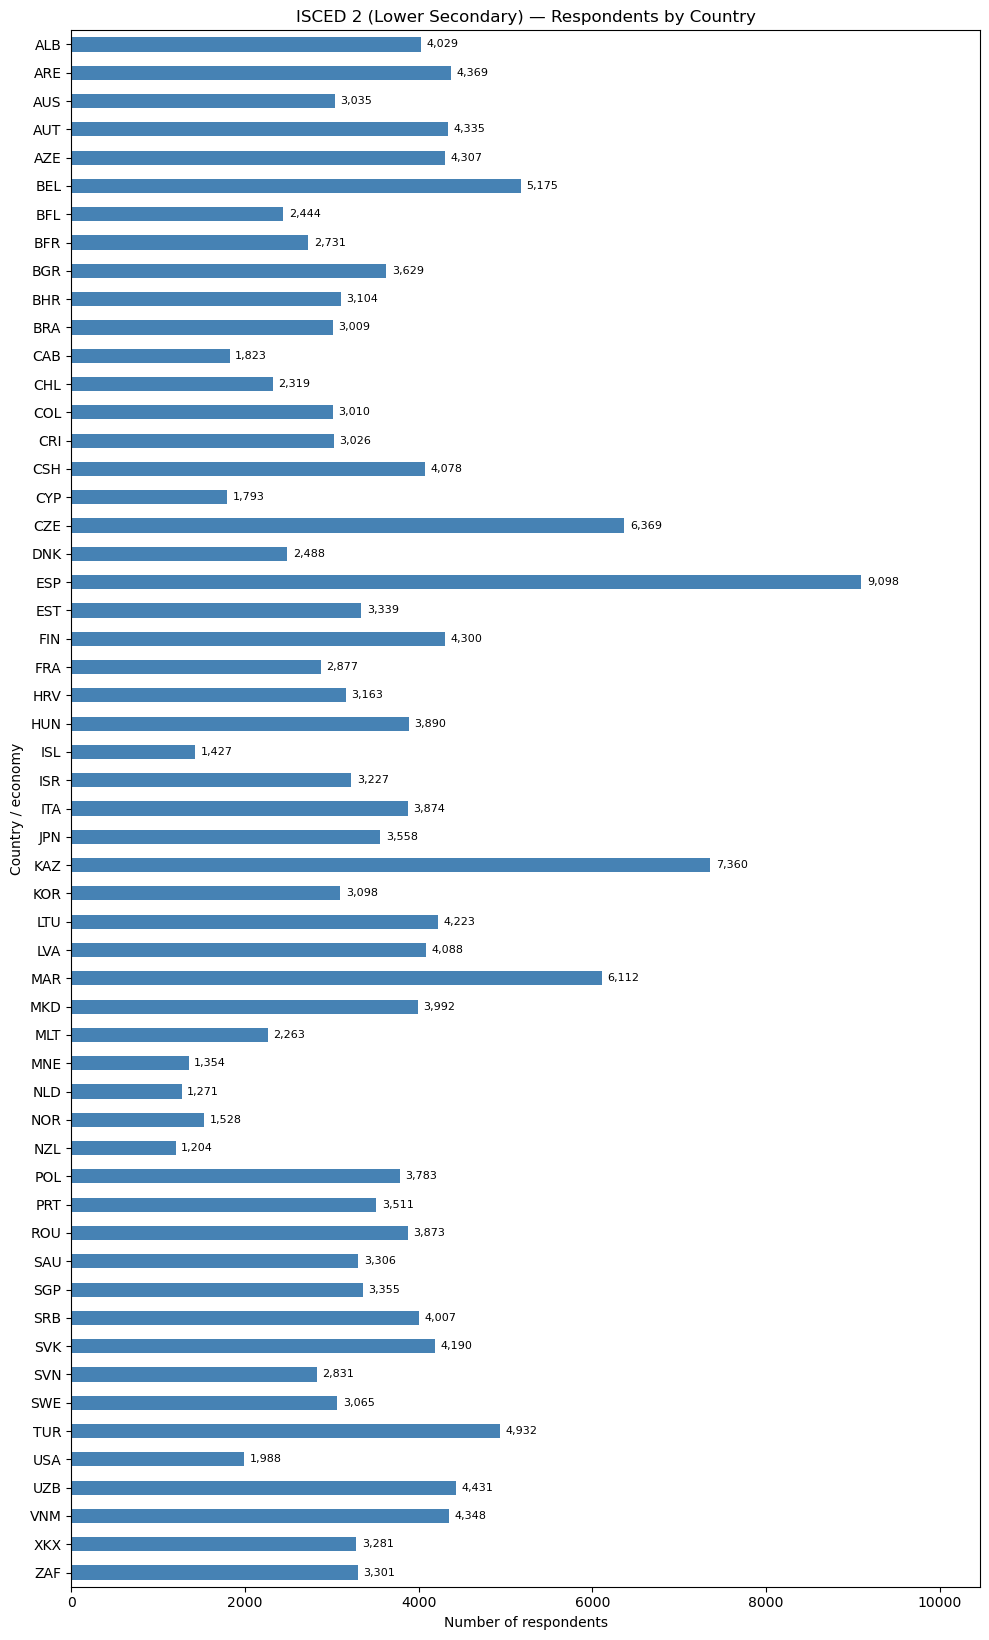

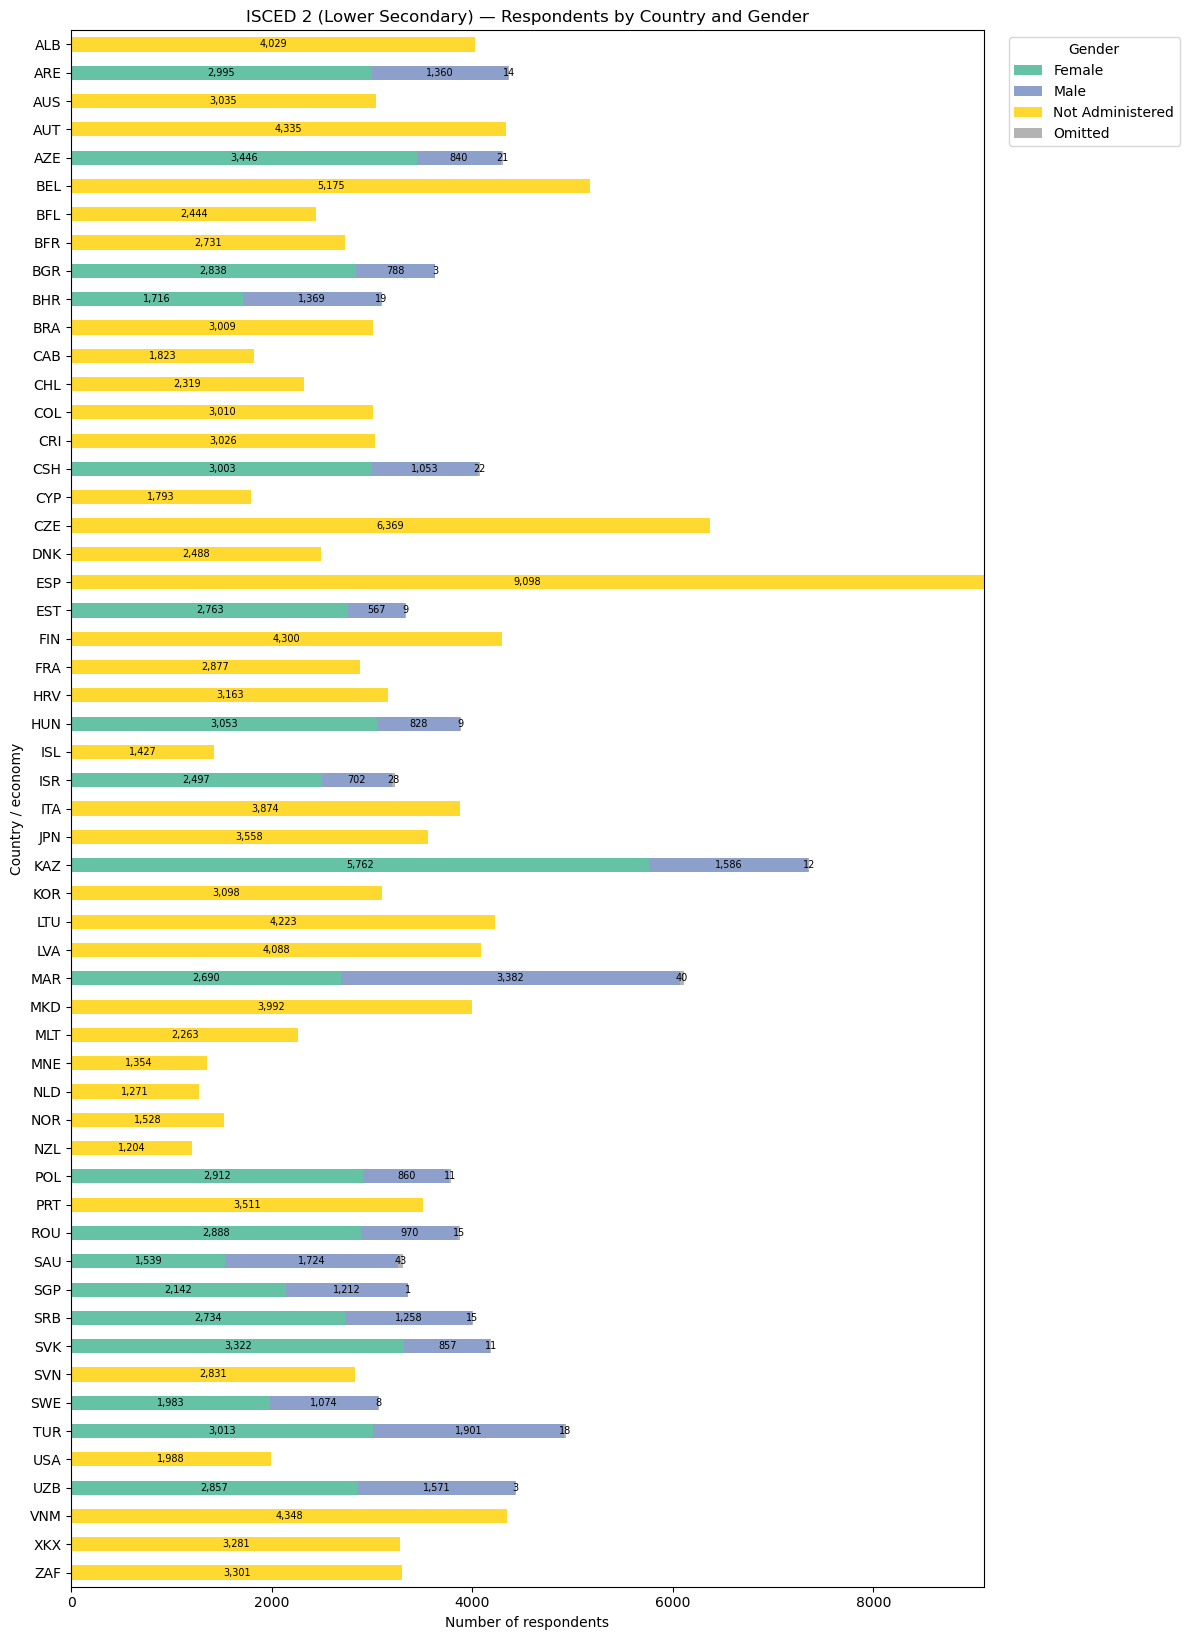


ISCED 3 (Upper Secondary): 28,225 respondents across 8 countries


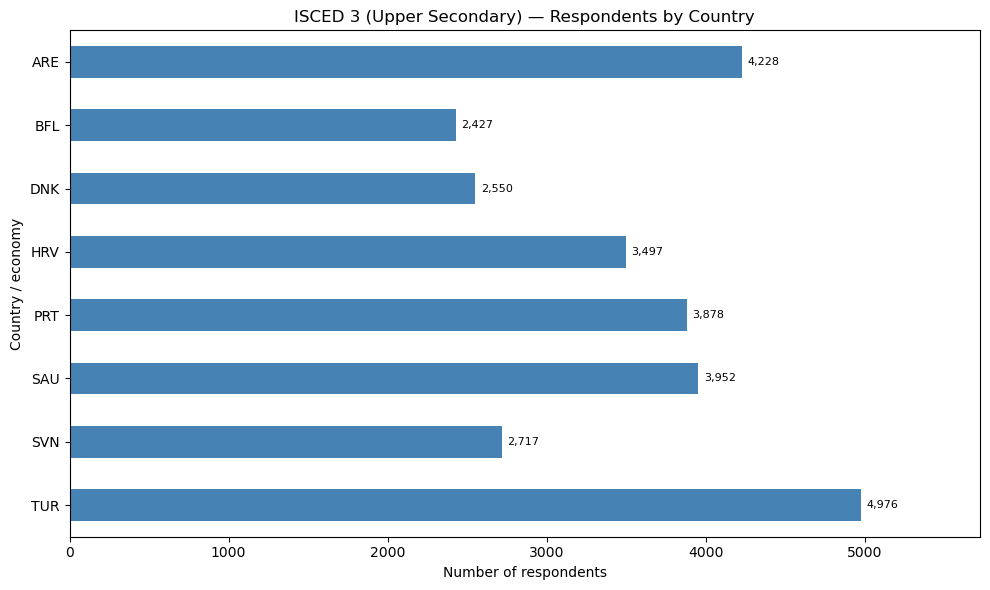

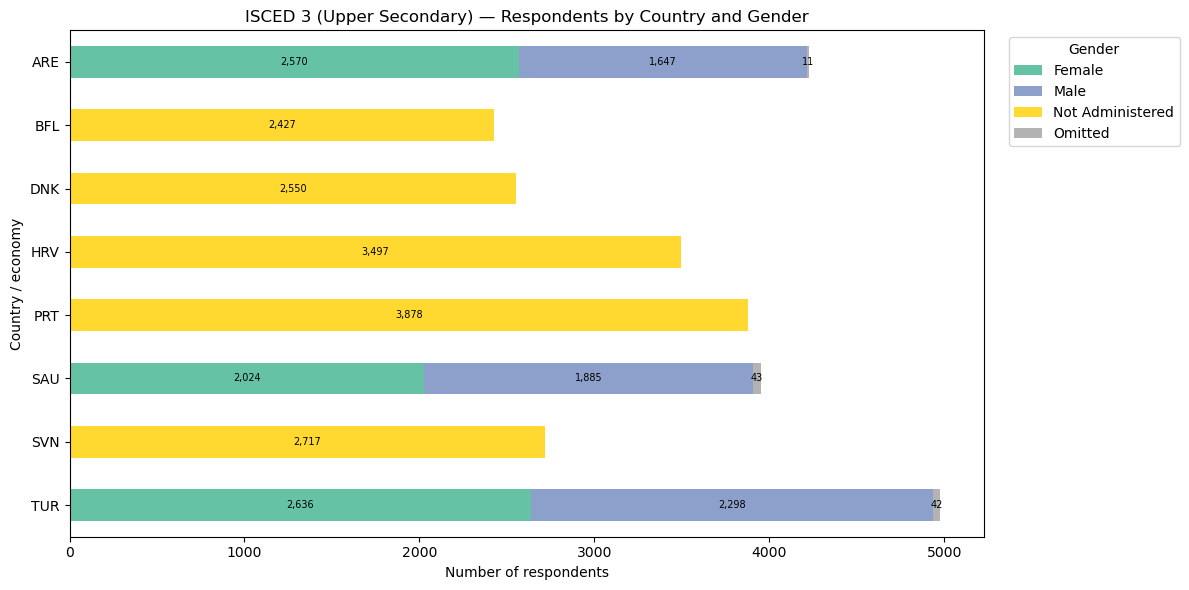

In [13]:
# ============================================================
# 9. Bar charts for each ISCED level (with count labels + gender labels)
# ============================================================
isced_labels = {
    1: 'ISCED 1 (Primary)',
    2: 'ISCED 2 (Lower Secondary)',
    3: 'ISCED 3 (Upper Secondary)'
}

# Map gender codes to readable labels — adjust if codebook says otherwise
gender_labels = {
    1: 'Female',
    2: 'Male',
    8: 'Not Administered',
    9: 'Omitted'
}

df = pd.read_csv("C:\\Users\\elif_\\Documents\\ttgintt4_renamed.csv")
target_pop_col = 'target_population_isced_level_1_isced_1_primary_2_isced_2_lo'
gender_col = 'gender'
country_col = 'country_economy_three_letter_code'


for isced_val, isced_name in isced_labels.items():
    df_isced = df[df[target_pop_col] == isced_val].copy()

    if len(df_isced) == 0:
        print(f"⚠️ No data found for {isced_name} — skipping")
        continue

    print(f"\n{isced_name}: {len(df_isced):,} respondents across {df_isced[country_col].nunique()} countries")

    # Recode gender for display
    df_isced['gender_label'] = df_isced[gender_col].map(gender_labels).fillna('Unknown')

    by_country = (
        df_isced[country_col]
        .value_counts()
        .sort_index(ascending=False)
    )

    by_country_gender = (
        df_isced.groupby([country_col, 'gender_label']).size().unstack(fill_value=0)
        .sort_index(ascending=False)
    )

    # Drop columns that are all zeros (e.g. if no 8/9 in this ISCED level)
    by_country_gender = by_country_gender.loc[:, (by_country_gender != 0).any(axis=0)]

    # ---- Chart 1: by country only ----
    fig, ax = plt.subplots(figsize=(10, max(6, len(by_country) * 0.3)))
    by_country.plot(kind='barh', ax=ax, color='steelblue')
    ax.bar_label(ax.containers[0],
                 labels=[f'{v:,}' for v in by_country],
                 padding=4, fontsize=8)
    ax.set_xlim(0, by_country.max() * 1.15)
    ax.set_xlabel('Number of respondents')
    ax.set_ylabel('Country / economy')
    ax.set_title(f'{isced_name} — Respondents by Country')
    plt.tight_layout()
    plt.show()

    # ---- Chart 2: by country and gender (stacked) ----
    fig, ax = plt.subplots(figsize=(12, max(6, len(by_country_gender) * 0.3)))
    by_country_gender.plot(kind='barh', stacked=True, ax=ax, colormap='Set2')

    for container, col in zip(ax.containers, by_country_gender.columns):
        vals = by_country_gender[col]
        # Only label segments with count > 0 to avoid clutter
        labels = [f'{v:,}' if v > 0 else '' for v in vals]
        ax.bar_label(container, labels=labels, label_type='center', fontsize=7)

    ax.set_xlabel('Number of respondents')
    ax.set_ylabel('Country / economy')
    ax.set_title(f'{isced_name} — Respondents by Country and Gender')
    ax.legend(title='Gender', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

C:\Users\elif_\AppData\Local\Temp\ipykernel_26976\1509299638.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['ai_use'] = df[ai_col].map(ai_value_map)



AI Use value counts (all ISCED):
ai_use
Missing    185489
No          53071
Yes         36762
Name: count, dtype: int64


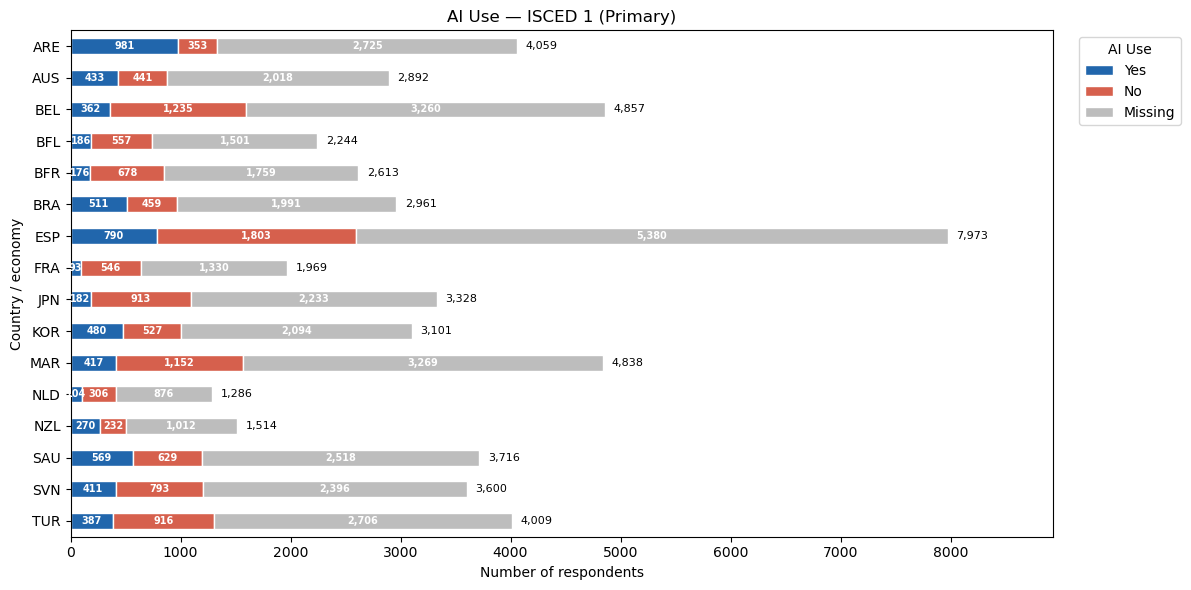

✅ Chart saved: ai_use_1_by_country.png


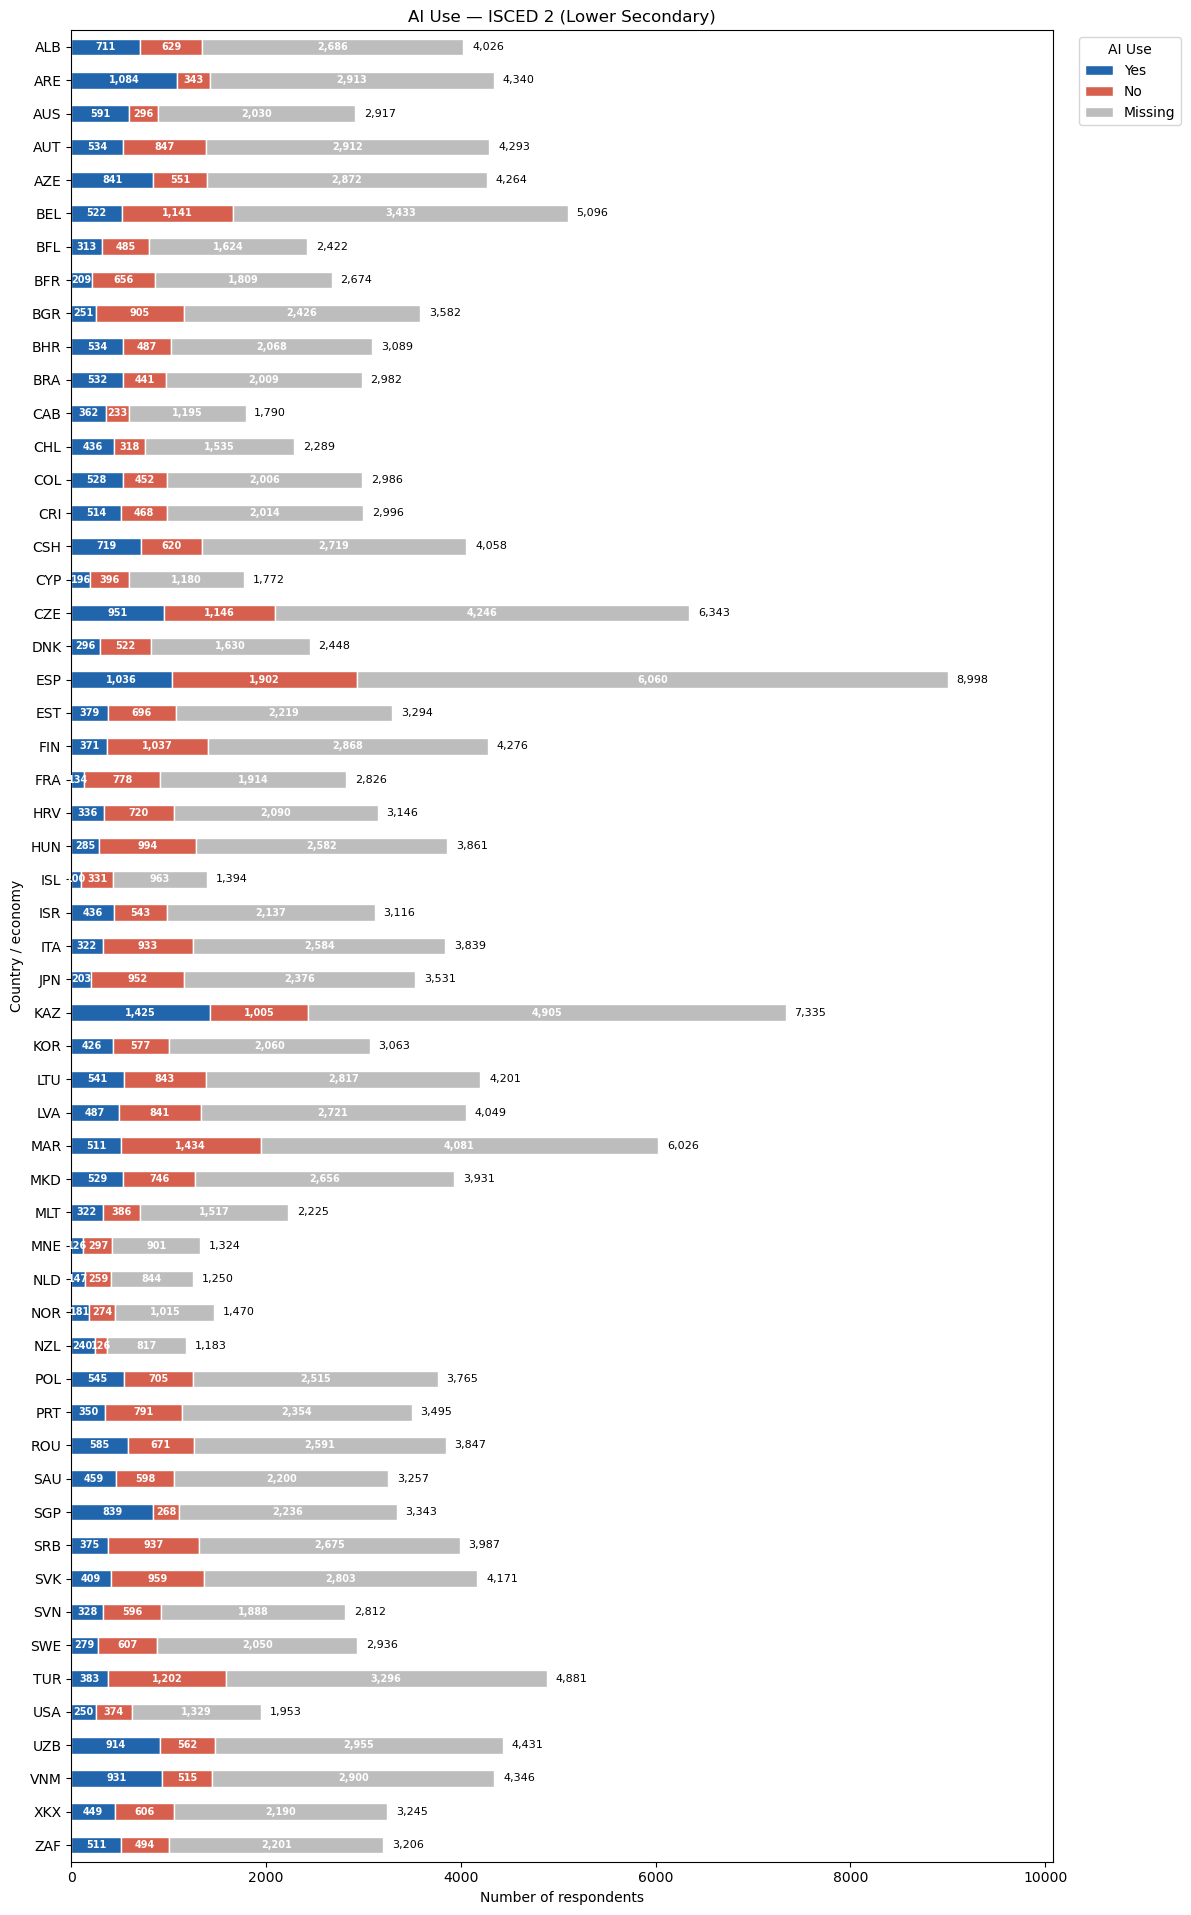

✅ Chart saved: ai_use_2_by_country.png


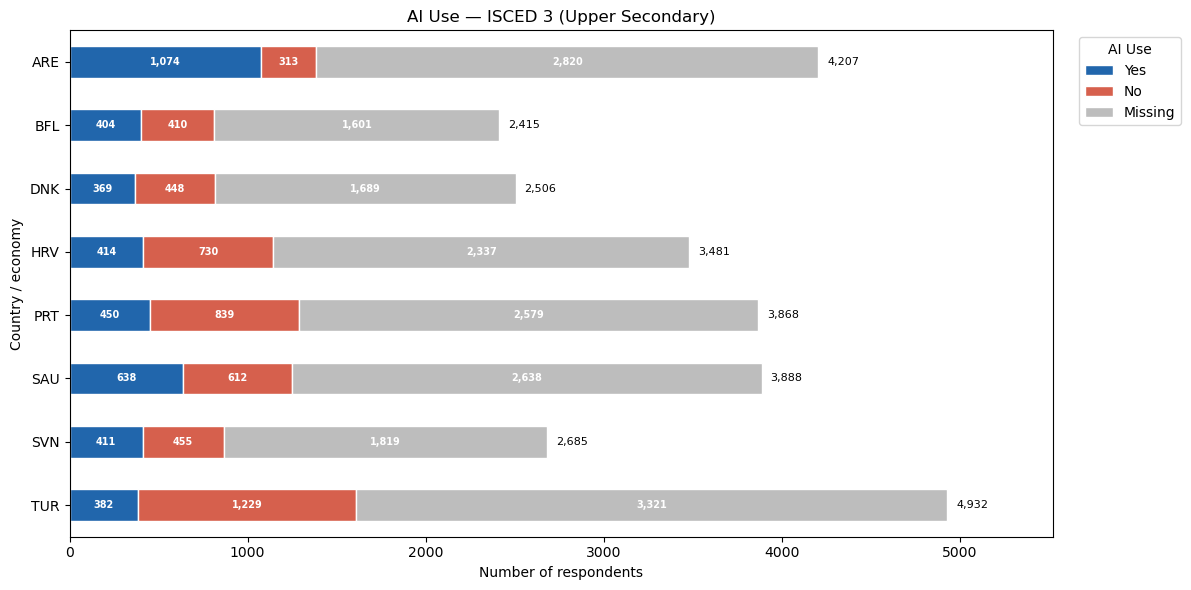

✅ Chart saved: ai_use_3_by_country.png


In [14]:
# ============================================================
# 10. AI Use by ISCED and Country (with count labels)
# ============================================================

country_col    = 'country_economy_three_letter_code'
gender_col     = 'gender'
target_pop_col = 'target_population_isced_level_1_isced_1_primary_2_isced_2_lo'
ai_col         = 'teacher_views_about_school_leadership_and_decision_making'

ai_value_map = {
    1: 'Yes', 2: 'No', 8: 'Missing',
    1.0: 'Yes', 2.0: 'No', 8.0: 'Missing'
}

df['ai_use'] = df[ai_col].map(ai_value_map)

print("\nAI Use value counts (all ISCED):")
print(df['ai_use'].value_counts())

category_order = ['Yes', 'No', 'Missing']
ai_colors = {'Yes': '#2166ac', 'No': '#d6604d', 'Missing': '#bdbdbd'}

for isced_val, isced_name in isced_labels.items():
    df_isced = df[df[target_pop_col] == isced_val].copy()

    if len(df_isced) == 0:
        print(f"⚠️ No data for {isced_name} — skipping")
        continue

    by_country_ai = (
        df_isced.groupby([country_col, 'ai_use'])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=category_order, fill_value=0)
        .sort_index(ascending=False)
    )

    # Drop Missing column if all zeros
    by_country_ai = by_country_ai.loc[:, (by_country_ai != 0).any(axis=0)]

    fig, ax = plt.subplots(figsize=(12, max(6, len(by_country_ai) * 0.35)))
    by_country_ai.plot(
        kind='barh', stacked=True, ax=ax,
        color=[ai_colors[c] for c in by_country_ai.columns],
        edgecolor='white'
    )

    # Count labels inside each segment
    for container, cat in zip(ax.containers, by_country_ai.columns):
        vals = by_country_ai[cat]
        labels = [f'{v:,}' if v > 0 else '' for v in vals]
        ax.bar_label(container, labels=labels,
                     label_type='center', fontsize=7,
                     color='white', fontweight='bold')

    # Total count at end of each bar
    totals = by_country_ai.sum(axis=1)
    for i, (country, total) in enumerate(totals.items()):
        ax.text(total + totals.max() * 0.01, i, f'{total:,}',
                va='center', ha='left', fontsize=8)

    ax.set_xlim(0, totals.max() * 1.12)
    ax.set_xlabel('Number of respondents')
    ax.set_ylabel('Country / economy')
    ax.set_title(f'AI Use — {isced_name}')
    ax.legend(title='AI Use', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(
        f"C:\\Users\\elif_\\Documents\\ai_use_{isced_val}_by_country.png",
        dpi=150, bbox_inches='tight'
    )
    plt.show()
    print(f"✅ Chart saved: ai_use_{isced_val}_by_country.png")

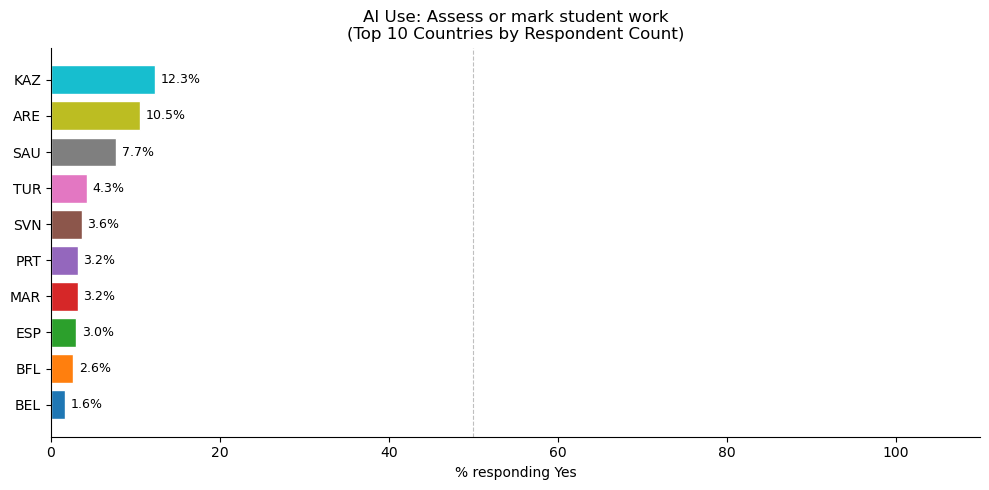

✅ Saved: ai_use_port_and_working_environment_a_top10.png


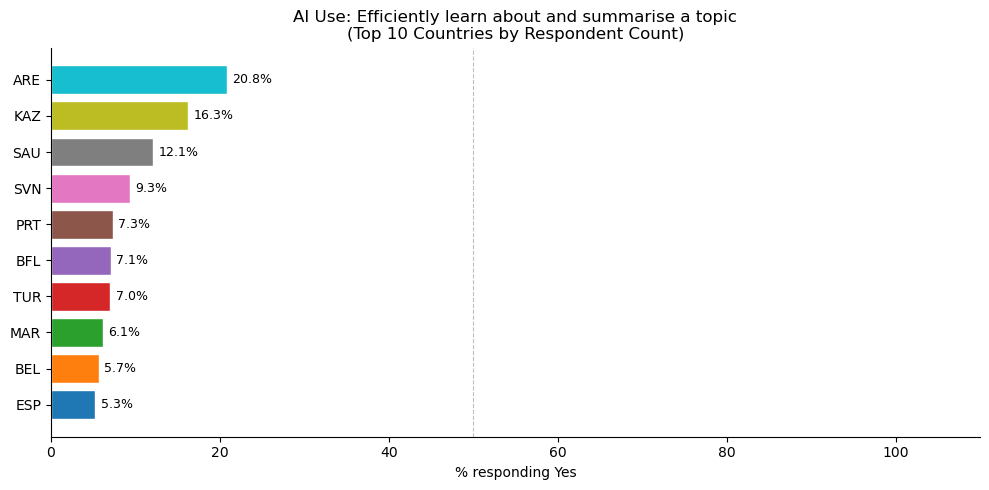

✅ Saved: ai_use_port_and_working_environment_b_top10.png


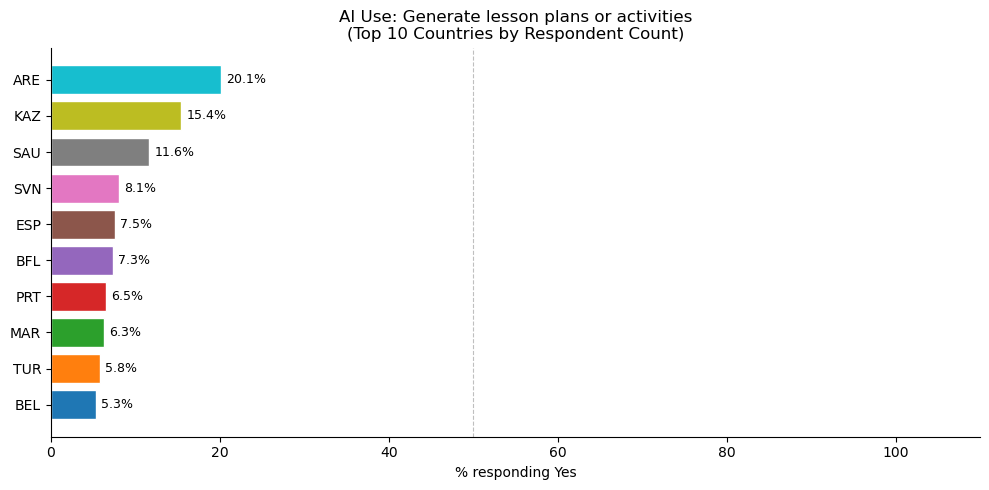

✅ Saved: ai_use_port_and_working_environment_c_top10.png


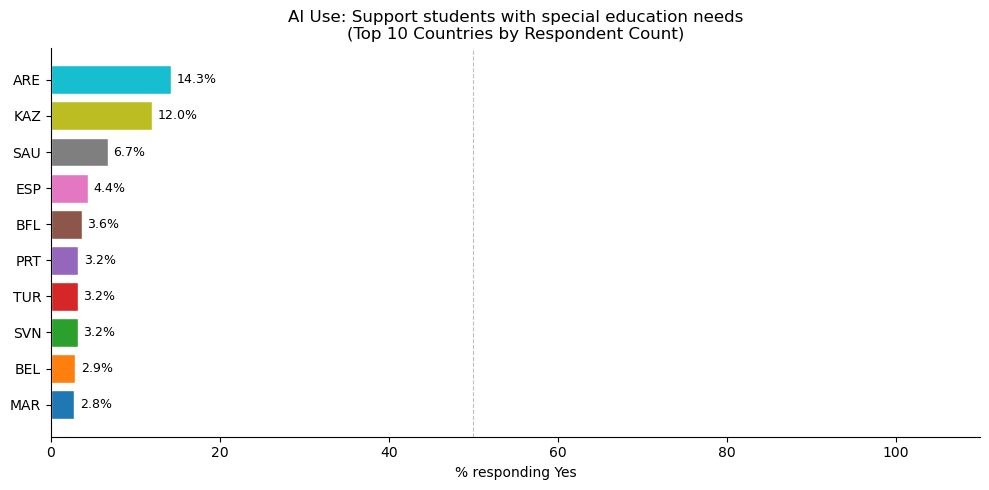

✅ Saved: ai_use_port_and_working_environment_d_top10.png


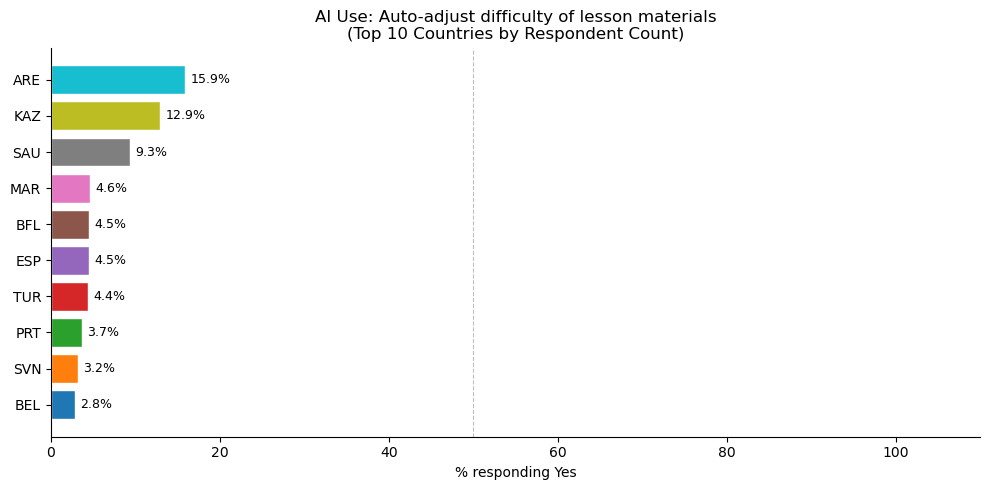

✅ Saved: ai_use_port_and_working_environment_e_top10.png


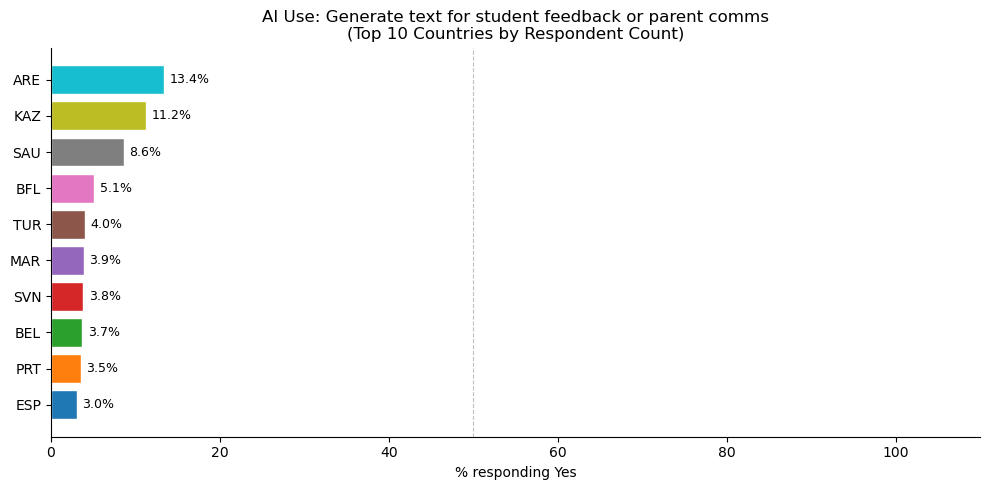

✅ Saved: ai_use_port_and_working_environment_f_top10.png


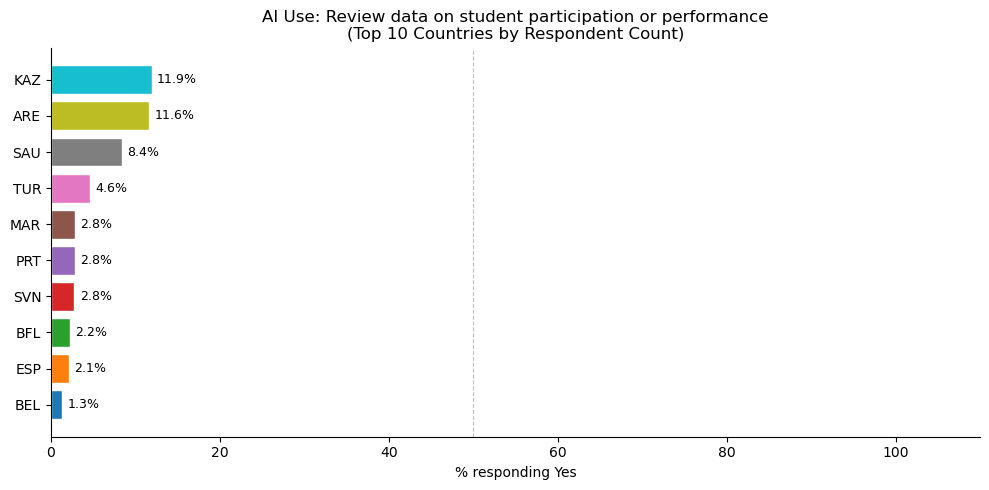

✅ Saved: ai_use_port_and_working_environment_g_top10.png


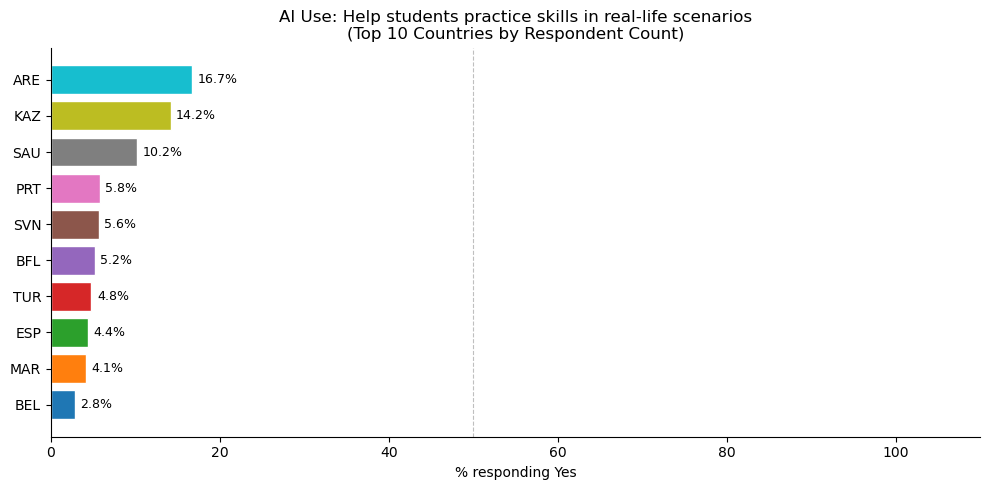

✅ Saved: ai_use_port_and_working_environment_h_top10.png


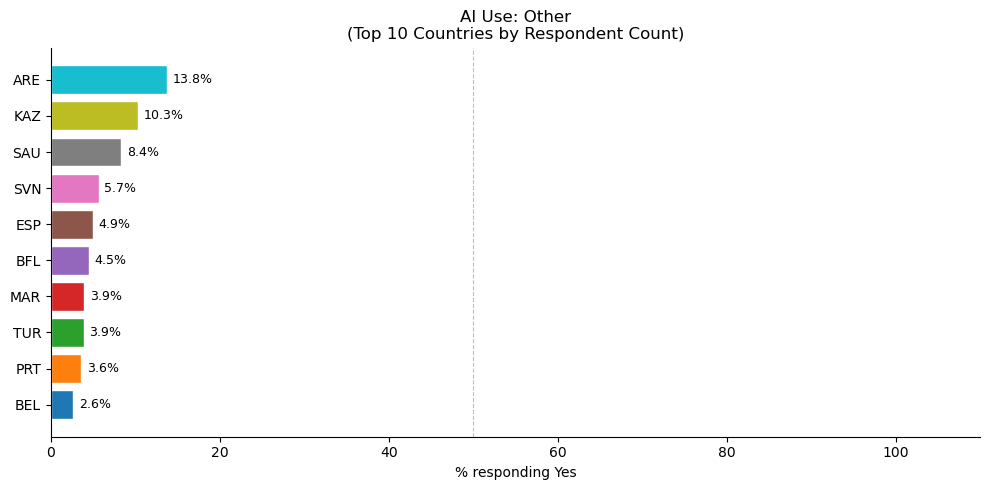

✅ Saved: ai_use_port_and_working_environment_i_top10.png


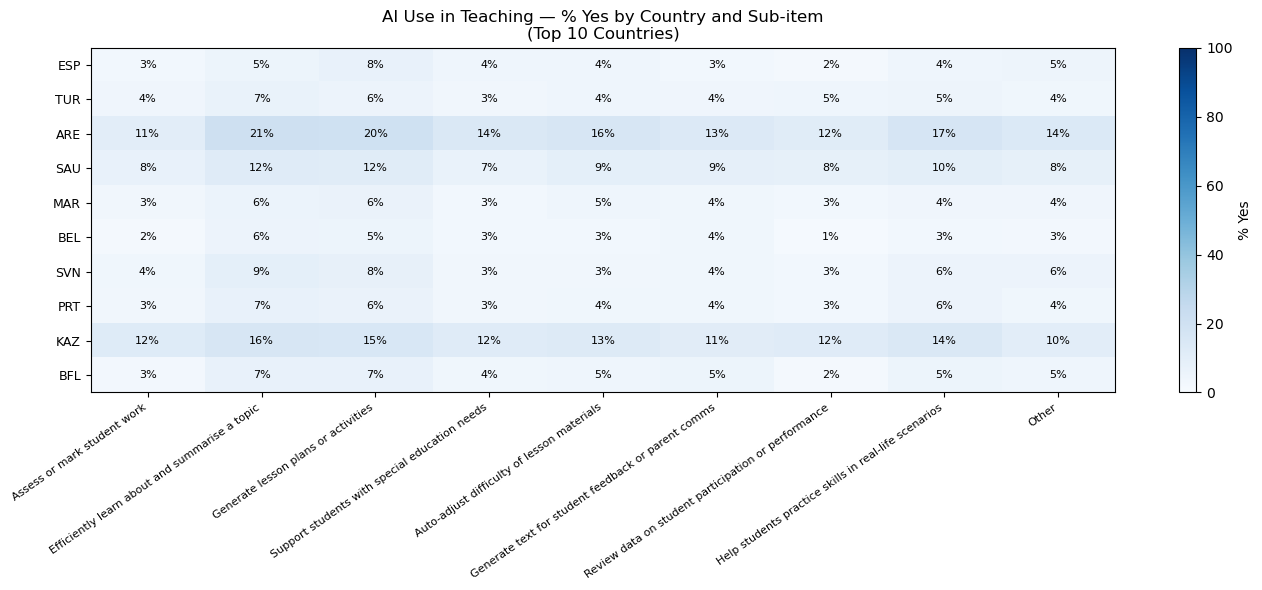

✅ Saved: ai_use_heatmap_top10.png


In [15]:
# ============================================================
# 8. AI Use in Teaching (TT4G37A-I) — % Yes for Top 10 Countries
# ============================================================

ai_cols = {
    'school_leadership_support_and_working_environment_a': 'Assess or mark student work',
    'school_leadership_support_and_working_environment_b': 'Efficiently learn about and summarise a topic',
    'school_leadership_support_and_working_environment_c': 'Generate lesson plans or activities',
    'school_leadership_support_and_working_environment_d': 'Support students with special education needs',
    'school_leadership_support_and_working_environment_e': 'Auto-adjust difficulty of lesson materials',
    'school_leadership_support_and_working_environment_f': 'Generate text for student feedback or parent comms',
    'school_leadership_support_and_working_environment_g': 'Review data on student participation or performance',
    'school_leadership_support_and_working_environment_h': 'Help students practice skills in real-life scenarios',
    'school_leadership_support_and_working_environment_i': 'Other',
}

yes_no_map = {1: 'Yes', 2: 'No', 1.0: 'Yes', 2.0: 'No'}

# Get top 10 countries by total respondent count
top10_countries = (
    df[country_col]
    .value_counts()
    .head(10)
    .index.tolist()
)

df_top10 = df[df[country_col].isin(top10_countries)].copy()

# ---- Chart per sub-item ----
for col, label in ai_cols.items():
    if col not in df.columns:
        print(f"⚠️ Column not found: {col}")
        continue

    # % Yes per country, top 10 only
    pct_yes = (
        df_top10.groupby(country_col)[col]
        .apply(lambda x: (x.map(yes_no_map) == 'Yes').sum() / x.notna().sum() * 100)
        .reindex(top10_countries)
        .sort_values(ascending=True)
    )

    colors = plt.cm.tab10.colors

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(
        pct_yes.index,
        pct_yes.values,
        color=[colors[i % len(colors)] for i in range(len(pct_yes))],
        edgecolor='white'
    )
    ax.bar_label(bars,
                 labels=[f'{v:.1f}%' for v in pct_yes.values],
                 padding=4, fontsize=9)
    ax.set_xlim(0, 110)
    ax.set_xlabel('% responding Yes')
    ax.set_title(f'AI Use: {label}\n(Top 10 Countries by Respondent Count)')
    ax.axvline(50, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    safe_name = col.replace(' ', '_')[-30:]
    plt.savefig(
        f"C:\\Users\\elif_\\Documents\\ai_use_{safe_name}_top10.png",
        dpi=150, bbox_inches='tight'
    )
    plt.show()
    print(f"✅ Saved: ai_use_{safe_name}_top10.png")

# ---- Summary heatmap: all sub-items × top 10 countries ----
import numpy as np

pct_matrix = pd.DataFrame({
    ai_cols[col]: (
        df_top10.groupby(country_col)[col]
        .apply(lambda x: (x.map(yes_no_map) == 'Yes').sum() / x.notna().sum() * 100)
        .reindex(top10_countries)
    )
    for col in ai_cols if col in df.columns
})

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(pct_matrix.values, aspect='auto', cmap='Blues', vmin=0, vmax=100)

ax.set_xticks(range(len(pct_matrix.columns)))
ax.set_xticklabels(pct_matrix.columns, rotation=35, ha='right', fontsize=8)
ax.set_yticks(range(len(pct_matrix.index)))
ax.set_yticklabels(pct_matrix.index, fontsize=9)

# Value annotations inside cells
for i in range(len(pct_matrix.index)):
    for j in range(len(pct_matrix.columns)):
        val = pct_matrix.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.0f}%',
                    ha='center', va='center', fontsize=8,
                    color='white' if val > 60 else 'black')

plt.colorbar(im, ax=ax, label='% Yes')
ax.set_title('AI Use in Teaching — % Yes by Country and Sub-item\n(Top 10 Countries)')
plt.tight_layout()
plt.savefig(
    "C:\\Users\\elif_\\Documents\\ai_use_heatmap_top10.png",
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✅ Saved: ai_use_heatmap_top10.png")

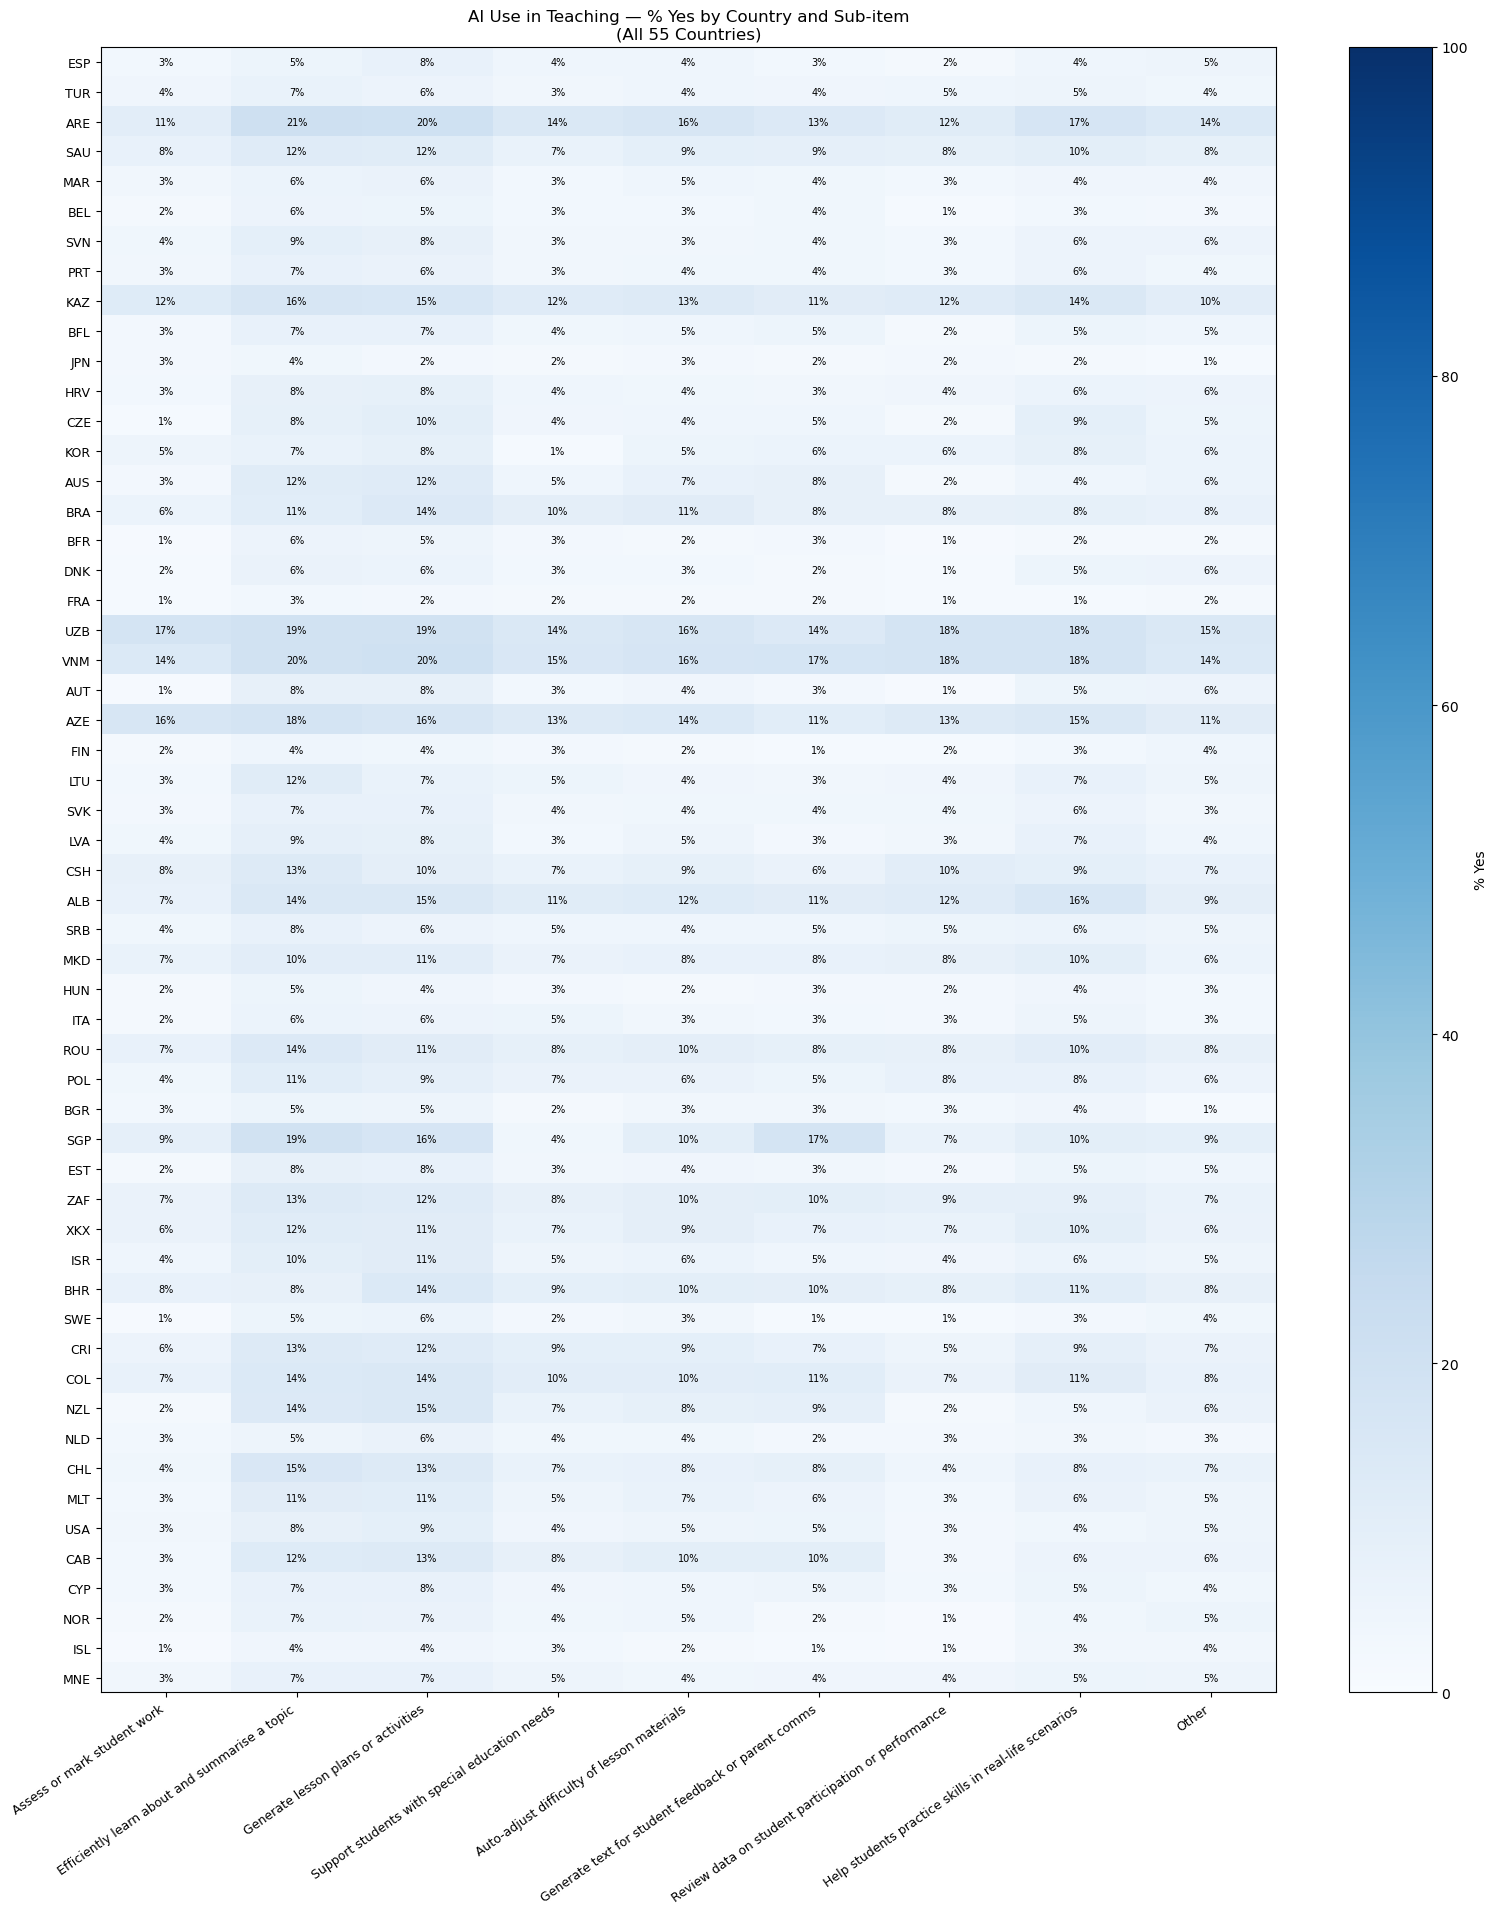

✅ Saved: ai_use_heatmap_all.png


In [19]:
# ============================================================
# 8. AI Use in Teaching (TT4G37A-I) — % Yes
# ============================================================


# Heatmap — all 55
pct_matrix_all = pd.DataFrame({
    ai_cols[col]: (
        df_all.groupby(country_col)[col]
        .apply(lambda x: (x.map(yes_no_map) == 'Yes').sum() / x.notna().sum() * 100)
        .reindex(all_55_countries)
    )
    for col in ai_cols if col in df.columns
})

fig, ax = plt.subplots(figsize=(16, max(14, len(pct_matrix_all) * 0.35)))
im = ax.imshow(pct_matrix_all.values, aspect='auto', cmap='Blues', vmin=0, vmax=100)
ax.set_xticks(range(len(pct_matrix_all.columns)))
ax.set_xticklabels(pct_matrix_all.columns, rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(len(pct_matrix_all.index)))
ax.set_yticklabels(pct_matrix_all.index, fontsize=9)
for i in range(len(pct_matrix_all.index)):
    for j in range(len(pct_matrix_all.columns)):
        val = pct_matrix_all.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                    fontsize=7, color='white' if val > 60 else 'black')
plt.colorbar(im, ax=ax, label='% Yes')
ax.set_title(f'AI Use in Teaching — % Yes by Country and Sub-item\n(All {len(pct_matrix_all)} Countries)')
plt.tight_layout()
plt.savefig("C:\\Users\\elif_\\Documents\\ai_use_heatmap_all.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: ai_use_heatmap_all.png")